# Target Variable Analysis

### 1. What is a Target Variable?

The target variable is the variable that we want our Machine Learning model to predict.

It is also called:

* Dependent variable
* Output variable
* Response variable
* Label

In my dataset:

Churn is the target variable.

It contains:

Yes → Customer left the company

No → Customer stayed with the company

Example:

Suppose a telecom company wants to predict:

"Will this customer leave the company?"

The model uses information such as:

* Age
* Tenure
* Monthly charges
* Contract type
* Internet service
* Payment method
* Support calls

to predict:

Churn = Yes / No

#### AI/ML usage

The target variable determines what type of Machine Learning problem we have.

| Target              | Problem        |
| ------------------- | -------------- |
| Yes / No            | Classification |
| Low / Medium / High | Classification |
| 0 / 1               | Classification |
| House price         | Regression     |
| Salary              | Regression     |
| Temperature         | Regression     |


In [3]:
import pandas as pd

df = pd.read_csv("customer_churn.csv")


In [4]:
df["Churn"].head()

0    Yes
1     No
2     No
3     No
4    Yes
Name: Churn, dtype: str

### 2. Identify the Target Variable

Before analyzing the target, we should explicitly identify it.

In [5]:
target = "Churn"

print("Target Variable:", target)
print("Target Data Type:", df[target].dtype)
print("Unique Target Values:", df[target].unique())

Target Variable: Churn
Target Data Type: str
Unique Target Values: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str


### 3. Class Distribution

Class distribution tells us how the observations are distributed among different target classes.

For my dataset, we want to know:

How many customers churned and how many customers did not churn?

My classes are:

Yes → Churned

No  → Did not churn

Example:

Suppose a telecom company has 5,020 customers.

If:

3,623 stayed

1,397 left

then most customers stayed.

Understanding this distribution is important before building a model.

#### AI/ML usage

Class distribution helps us:

* Understand the target
* Detect class imbalance
* Select appropriate evaluation metrics
* Decide whether resampling may be necessary
* Avoid misleading model accuracy

In [6]:
class_distribution = df["Churn"].value_counts()

print(class_distribution)

Churn
No     3623
Yes    1397
Name: count, dtype: int64


So:

No churn: 3,623 customers

Yes churn: 1,397 customers

### 4. Class Counts

Class count is the number of observations belonging to each class.

In my dataset:

No  → 3623

Yes → 1397

Example:

Imagine a bank wants to predict whether customers will default on loans.

No Default  → 950 customers

Default     → 50 customers

The class counts tell us that default cases are much fewer.

The same idea applies to my churn dataset.

#### AI/ML usage

Class counts are useful for identifying whether one class is much larger than another.

This becomes particularly important when training classification models.

In [7]:
print("Customers who did not churn:", (df["Churn"] == "No").sum())
print("Customers who churned:", (df["Churn"] == "Yes").sum())

Customers who did not churn: 3623
Customers who churned: 1397


### 5. Class Percentages

Class percentage tells us what percentage of the entire dataset belongs to each class.

The formula is:

$Class Percentage=\frac{Total Observations}{Class Count}×100$

My dataset contains:

Total customers = 5020

For No :      $\frac{5020}{3623}×100 ≈ 72.17% $

For Yes :     $\frac{5020}{1397} ×100 ≈ 27.83% $

Approximately:

72.17% of customers stayed, while 27.83% churned.

That means roughly 1 out of every 4 customers churned.

In [8]:
class_percentages = df["Churn"].value_counts(normalize=True) * 100

print(class_percentages)

Churn
No     72.171315
Yes    27.828685
Name: proportion, dtype: float64


### 6. Class Imbalance

Class imbalance occurs when the classes in the target variable are not represented equally.

For example:

Class A → 95%

Class B → 5%

would be highly imbalanced.

My dataset:

No  → 72.17%

Yes → 27.83%

There is a noticeable difference between the classes.

Is my dataset imbalanced?

It is moderately imbalanced, but not extremely imbalanced.

The majority class is:

No → 72.17%

The minority class is:

Yes → 27.83%

A useful way to quantify this is the imbalance ratio:

$Imbalance Ratio=\frac{Minority Class}{Majority Class}$

For my dataset:

$\frac{1397}{3623} ≈ 2.59$

So there are approximately 2.59 non-churn customers for every 1 churn customer.

In [9]:
class_counts = df["Churn"].value_counts()

majority_class = class_counts.max()
minority_class = class_counts.min()

imbalance_ratio = majority_class / minority_class

print("Majority Class Count:", majority_class)
print("Minority Class Count:", minority_class)
print("Imbalance Ratio:", round(imbalance_ratio, 2))

Majority Class Count: 3623
Minority Class Count: 1397
Imbalance Ratio: 2.59


### 7. Why Class Imbalance Matters in Machine Learning

Imagine we create a very simple model:

"Predict No for every customer."

Since 72.17% of customers are No, the model would achieve approximately:

72.17% accuracy

without identifying even a single customer who churns.

That's a major problem for a business.

Example:

Suppose a telecom company uses the model to identify customers who may leave.

If the model predicts:

Everyone → No Churn

it might have decent accuracy, but the company would fail to identify customers who are actually leaving.

Therefore, accuracy alone is not enough when the target classes are imbalanced.

#### AI/ML usage

For churn prediction, we should also consider:

* Precision
* Recall
* F1-score
* Confusion Matrix
* ROC-AUC

Especially:

Recall for the Churn = Yes class

because the company may want to identify as many potential churn customers as possible.

### 8. Visualizing Class Distribution

A bar chart is one of the simplest ways to understand target distribution.

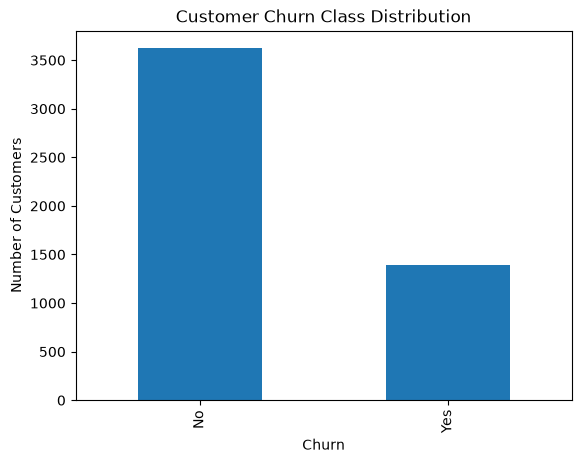

In [10]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Class Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

Interpretation

The No class has significantly more observations than the Yes class.

### 9. Class Percentage Visualization

We can also visualize percentages using a pie chart.

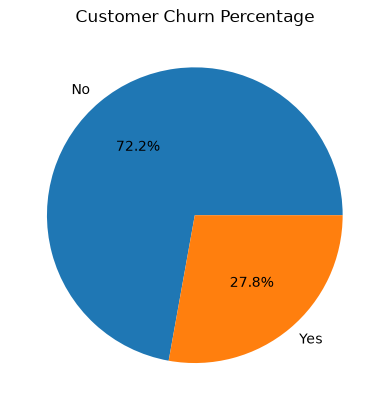

In [11]:
df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Customer Churn Percentage")
plt.ylabel("")
plt.show()